In [109]:
import numpy as np, pandas as pd
from sklearn.model_selection import GroupShuffleSplit

BASE = "/kaggle/input/competitions/shopee-product-matching"
df = pd.read_csv(f"{BASE}/train.csv")
SEED = 42

In [110]:
df.head()

,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [111]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_i, rest_i = next(gss.split(df, groups=df.label_group))
train = df.iloc[train_i].reset_index(drop=True)
rest = df.iloc[rest_i]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_i, test_i = next(gss2.split(rest, groups=rest.label_group))
val = rest.iloc[val_i].reset_index(drop=True)
test = rest.iloc[test_i].reset_index(drop=True)

for name, d in [("train", train), ("val", val), ("test", test)]:
    print(name, len(d), d.label_group.nunique())
assert not set(val.label_group) & set(test.label_group)
assert not set(train.label_group) & set(val.label_group)

train 23724 7709
val 5115 1652
test 5411 1653


## Train / validation / test split

I split `train.csv` by `label_group`, not by row, using
`GroupShuffleSplit` with seed 42 (70% / 15% / 15% of groups).

**Why by group.** [Your reason: the real test set holds groups never
seen in training, and a row-level split would put listings of the
same product on both sides and inflate the score.]

| Split | Listings | Groups |
|---|---|---|
| train | 23,724 | 7,709 |
| val | 5,115 | 1,652 |
| test | 5,411 | 1,653 |

Totals match the full data (34,250 listings, 11,014 groups), and
assertions confirm no group appears in more than one split.


**A caveat.** Group shares are exact but listing shares are not
(69.3 / 14.9 / 15.8%), because group sizes differ. Test has slightly
more listings per group (about 3.27 vs 3.10 for val), so the two
splits may not be equally hard. [I have not checked why.]

In [112]:
import numpy as np, pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def set_f1(pred_sets, labels):
    labels = np.asarray(labels)
    sizes = pd.Series(labels).map(pd.Series(labels).value_counts()).values
    f1 = np.empty(len(labels))
    for i, P in enumerate(pred_sets):
        P = np.asarray(P)
        inter = (labels[P] == labels[i]).sum()
        f1[i] = 2 * inter / (len(P) + sizes[i])
    return f1.mean()

def prec_rec(pred_sets, labels):
    labels = np.asarray(labels)
    sizes = pd.Series(labels).map(pd.Series(labels).value_counts()).values
    ps, rs = [], []
    for i, P in enumerate(pred_sets):
        P = np.asarray(P)
        inter = (labels[P] == labels[i]).sum()
        ps.append(inter / len(P))
        rs.append(inter / sizes[i])
    return np.mean(ps), np.mean(rs)

def predict(S, thr):
    return [np.where(S[i] >= thr)[0] for i in range(len(S))]

def run_sweep(vec, fit_texts, thresholds=np.arange(0.2, 0.96, 0.05)):
    vec.fit(fit_texts)
    Sx = cosine_similarity(vec.transform(val.title))
    np.fill_diagonal(Sx, 1.0)
    res = [(round(t, 2), set_f1(predict(Sx, t), lab)) for t in thresholds]
    best = max(res, key=lambda r: r[1])
    return Sx, res, best

## Evaluation metric

Mean set-based F1. For each listing I compare the set of listings I
predict as matches (including itself) with its true group:
F1 = 2·|P ∩ T| / (|P| + |T|), then average over all listings.

**Why F1 and not accuracy.** nearly all pairs are
non-matches, so accuracy would be high for a model that finds
nothing. F1 penalises both missed matches and false matches . Since F1 score is the harmonic mean of precision and recall , it considers both of them which makes it better 

**Sanity checks on val**

| Baseline | Mean set-F1 |
|---|---|
| Predict everything | 0.0021 |
| Self only (floor) | 0.4629 |
| Perfect | 1.0000 |

The self-only score matches the formula mean(2 / (g + 1)). [Why the
floor is so high: 63% of groups are pairs, so predicting only
yourself already gets about half the credit.]

In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vec = TfidfVectorizer(lowercase=True)
vec.fit(train.title)
S = cosine_similarity(vec.transform(val.title))
np.fill_diagonal(S, 1.0)

In [114]:
def predict(S, thr):
    return [np.where(S[i] >= thr)[0] for i in range(len(S))]

results = [(round(t, 2), set_f1(predict(S, t), lab))
           for t in np.arange(0.2, 0.96, 0.05)]
print(results[:3])

[(np.float64(0.2), np.float64(0.43779089154199496)), (np.float64(0.25), np.float64(0.5583722989812839)), (np.float64(0.3), np.float64(0.6506672975529207))]


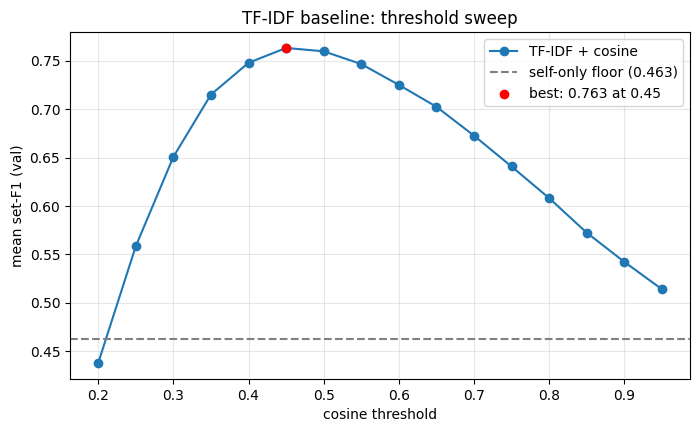

In [115]:
import os
import matplotlib.pyplot as plt

thr, f1 = zip(*results)
best_thr, best_f1 = max(results, key=lambda r: r[1])

plt.figure(figsize=(8, 4.5))
plt.plot(thr, f1, marker="o", label="TF-IDF + cosine")
plt.axhline(0.4629, color="gray", linestyle="--", label="self-only floor (0.463)")
plt.scatter([best_thr], [best_f1], color="red", zorder=3,
            label=f"best: {best_f1:.3f} at {best_thr}")
plt.xlabel("cosine threshold")
plt.ylabel("mean set-F1 (val)")
plt.title("TF-IDF baseline: threshold sweep")
plt.legend()
plt.grid(alpha=0.3)

os.makedirs("/kaggle/working/results", exist_ok=True)
plt.savefig("/kaggle/working/results/tfidf_threshold_sweep.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Baseline: TF-IDF + cosine similarity

TF-IDF on titles, fitted on the train split only, cosine similarity
between every pair of val listings, and a threshold to decide matches.

| Threshold | Mean set-F1 (val) |
|---|---|
| 0.20 | 0.4378 |
| 0.45 (best) | 0.7632 |
| 0.95 | 0.5140 |

- Best threshold 0.45, F1 0.7632, against a floor of 0.4629.
- Too many titles clear the bar, so predicted sets are large and full of wrong listings. Precision collapses, and the score ends up worse than predicting nothing. This is the "everything" failure in miniature.
- Only near-identical titles pass, so predicted sets shrink toward "just me". It stays a little above 0.4629 because exact-duplicate titles still link.
- The peak isn't sharp, so any choice in this range is nearly as good, and the final number isn't fragile to the exact threshold.

In [116]:
i = 0
top = np.argsort(-S[i])[:5]
print(val.title[i])
for j in top:
    print(round(S[i, j], 2), val.title[j])

Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DOUBLE FOAM TAPE
1.0 Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DOUBLE FOAM TAPE
0.69 DOUBLE TAPE BUSA 3M Pe Foam Tape 24mm x 4M ORIGINAL
0.69 DOUBLE TAPE BUSA 3M Pe Foam Tape 24mm x 4M ORIGINAL
0.69 DOUBLE TAPE BUSA 3M Pe Foam Tape 24mm x 4M ORIGINAL
0.63 Double Tip / Double Sided Tape Perekat 2 Sisi Joyko 6 mm x 15 yard Double Tape


In [117]:
def predict(S, thr):
    return [np.where(S[i] >= thr)[0] for i in range(len(S))]

results = []
for thr in np.arange(0.2, 0.96, 0.05):
    results.append((round(thr, 2), set_f1(predict(S, thr), lab)))

for thr, f in results:
    print(thr, round(f, 4))

0.2 0.4378
0.25 0.5584
0.3 0.6507
0.35 0.715
0.4 0.7479
0.45 0.7632
0.5 0.7597
0.55 0.7466
0.6 0.7251
0.65 0.7025
0.7 0.6726
0.75 0.6408
0.8 0.6081
0.85 0.5724
0.9 0.5423
0.95 0.514


## Error Analysis

In [118]:
from collections import defaultdict
thr = 0.45
pred = predict(S, thr)

members = defaultdict(list)
for idx, l in enumerate(lab):
    members[l].append(idx)

tp, fp, fn = [], [], []
for i, P in enumerate(pred):
    Pset = set(P)
    for j in P:
        if j != i:
            (tp if lab[j] == lab[i] else fp).append((S[i, j], i, j))
    for j in members[lab[i]]:
        if j != i and j not in Pset:
            fn.append((S[i, j], i, j))

print(len(tp), len(fp), len(fn))

def show(pairs, k=6):
    for s, i, j in pairs[:k]:
        print(round(s, 2), "|", val.title[i], "  ||  ", val.title[j])

print("FALSE MATCHES (highest score first)")
show(sorted(fp, reverse=True))
print("MISSED MATCHES (lowest score first)")
show(sorted(fn))
print("CORRECT MATCHES")
show(sorted(tp, reverse=True)[:3] + sorted(tp)[:3], k=6)

15024 7316 6998
FALSE MATCHES (highest score first)
1.0 | Ecolink LED 8 Watt Lampu Bohlam Cool Day Light (Putih)   ||   Ecolink LED 6 Watt Lampu Bohlam Cool Day Light (Putih)
1.0 | Ecolink LED 6 Watt Lampu Bohlam Cool Day Light (Putih)   ||   Ecolink LED 8 Watt Lampu Bohlam Cool Day Light (Putih)
1.0 | BRISA JILBAB KHIMAR MURAH JilbabStyle HIjabMuslimah HIjabStyle JilbabInstan   ||   BRISA JILBAB KHIMAR MURAH JilbabStyle HIjabMuslimah HIjabStyle JilbabInstan
1.0 | Powerbank ROBOT 10000mAh RT100Q Led Dual Port USB Quick Charge Fast Charging Garansi Resmi 1 Tahun   ||   Powerbank ROBOT 10000mAh RT130 Led Dual Port USB Quick Charge Fast Charging Garansi Resmi 1 Tahun
1.0 | Powerbank ROBOT 10000mAh RT130 Led Dual Port USB Quick Charge Fast Charging Garansi Resmi 1 Tahun   ||   Powerbank ROBOT 10000mAh RT100Q Led Dual Port USB Quick Charge Fast Charging Garansi Resmi 1 Tahun
1.0 | BRISA JILBAB KHIMAR MURAH JilbabStyle HIjabMuslimah HIjabStyle JilbabInstan   ||   BRISA JILBAB KHIMAR MURAH Ji

In [119]:
an = vec.build_analyzer()
print(an("Ecolink LED 8 Watt Lampu"))          # is '8' missing?
print("rt130" in vec.vocabulary_, "rt100q" in vec.vocabulary_)

['ecolink', 'led', 'watt', 'lampu']
False False


In [120]:
near = [p for p in fn if 0.25 <= p[0] < 0.45 and p[1] < p[2]]
near.sort(reverse=True)
show(near, k=6)

0.45 | SNEAKERS PRIA NEW FASH   ||   NEW!!! SEPATU SNEAKERS XBO SPORT
0.45 | Velvet Junior Short Sleeve Tee Baju Lengan Pendek Bayi Isi 3 Pcs   ||   3Stel Velvet Junior Kaos Oblong Bayi Lengan Pendek Lembut S M L
0.45 | NAT C 1000 MENINGKATKAN DAYA TAHAN TUBUH ISI 30 TABLETS   ||   NAT C 1000 ISI 30 TAB MEGAWECARE PRODUK ORIGINAL
0.45 | Easy Touch Gula darah / Stik Gula Darah   ||   Strip Easy Touch Glukosa / Strip Cek Gula Darah Diabetes / Strip isi ulang MURAH
0.45 | SKIN AQUA SKINAQUA MOISTURE MILK / MILD MILK / MOISTURE GEL / MOISTURE MILK SERIES   ||   [SPF 50] Skin Aqua UV Moisture Milk SPF 50 40GR
0.45 | Kaos Kaki Gaya Korea Motif Garis Bahan Katun untuk Wanita / Musim Gugur   ||   KAOS KAKI GARIS KAOS KAKI SEKOLAH


## Error analysis (TF-IDF, threshold 0.45, val)

At 0.45 the pairwise precision is 0.672 and recall 0.682.

**False matches.** Ecolink LED 8W vs 6W , score 1.0. The titles differ only in 8 and 6 and cosine gives a perfect score. My explanation would be that the defaullt tokeniser drops single character tokens so both digits vanish and the vectors become identical. ROBOT powerbank RT100Q vs RT130, score 1.0. These model codes are whole tokens, so they shouldn't vanish like a single digit. A likely cause is that neither code appears in the train vocabulary, and a vectoriser fitted on train ignores unknown words.

**Missed matches.** "CLB / GB GLOW EMBOS..." vs "AYY SKINCARE..." share no word at all. These are brand and seller codes, and text can't link them.

**Correct matches.** Score 0.45, "Saringan Air Zernii / Filter Penyaring Air" vs "ZERNII WATER FILTER ALAT LENGKAP": matched on the brand word alone, across Indonesian and English. That's near the threshold, and one more word of difference would have lost it.

In [121]:
def prec_rec(pred_sets, labels):
    labels = np.asarray(labels)
    sizes = pd.Series(labels).map(pd.Series(labels).value_counts()).values
    ps, rs = [], []
    for i, P in enumerate(pred_sets):
        P = np.asarray(P)
        inter = (labels[P] == labels[i]).sum()
        ps.append(inter / len(P))
        rs.append(inter / sizes[i])
    return np.mean(ps), np.mean(rs)

In [122]:
S1, res1, best1 = run_sweep(
    TfidfVectorizer(lowercase=True, token_pattern=r"(?u)\b\w+\b"), train.title)
print("single-char kept:", best1)

single-char kept: (np.float64(0.45), np.float64(0.7649677585343213))


## Experiment 1: keep single-character tokens

**Motivation.** In the error analysis, "Ecolink LED 8 Watt" and "...6 Watt"
scored exactly 1.0. Running the vectoriser's analyzer on the title showed
that the default tokenizer drops tokens shorter than two characters, so the
"8" and "6" never reached the vectors.

**Change.** `token_pattern=r"(?u)\b\w+\b"`, everything else as the baseline.

**Result.** Best val F1 0.7650 at 0.45, against 0.7632 for the baseline.
The gain of 0.0018 comes from one split with no repeats, so I treat it as
too small to call an improvement. The Ecolink pair fell from 1.0 to 0.931.

**Observation.** The change worked mechanically, but the pair is still far
above any usable threshold. One differing token in an otherwise identical
title is a small share of the vector. In the baseline sweep, thresholds
high enough to separate such pairs (0.90 and 0.95) scored 0.5423 and 0.514,
near the floor, so a single global threshold cannot remove these false
matches without losing recall elsewhere.

In [123]:
mask8 = val.title.str.contains("Ecolink LED 8 Watt", regex=False)
mask6 = val.title.str.contains("Ecolink LED 6 Watt", regex=False)
i8, i6 = val.index[mask8][0], val.index[mask6][0]

print("8W vs 6W, baseline :", round(S[i8, i6], 3))
print("8W vs 6W, 1-char kept:", round(S1[i8, i6], 3))

8W vs 6W, baseline : 1.0
8W vs 6W, 1-char kept: 0.931


In [124]:
S2, res2, best2 = run_sweep(TfidfVectorizer(lowercase=True), val.title)
print("fitted on val titles:", best2)

ia = val.index[val.title.str.contains("RT100Q", regex=False)][0]
ib = val.index[val.title.str.contains("RT130", regex=False)][0]
print("RT100Q vs RT130, baseline  :", round(S[ia, ib], 3))
print("RT100Q vs RT130, fit on val:", round(S2[ia, ib], 3))

fitted on val titles: (np.float64(0.4), np.float64(0.776320708078831))
RT100Q vs RT130, baseline  : 0.345
RT100Q vs RT130, fit on val: 0.322


## Experiment 2: fit the vectoriser on the val titles

**Motivation.** "RT100Q" and "RT130" (two powerbank models) were not in the
train vocabulary, so a vectoriser fitted on train ignored them and the two
titles became identical (similarity 1.0). Fitting on the titles being
searched needs no labels, so it does not leak the answer.

**Change.** `TfidfVectorizer(lowercase=True)` fitted on `val.title`.

**Result.** Best val F1 **0.7763 at threshold 0.40** (baseline 0.7632 at
0.45), a gain of 0.0131. The RT100Q/RT130 pair fell from 1.0 (baseline and
experiment 1) to 0.906.

**Observation.** The vocabulary explanation held: the score only changed
once the codes became tokens. The pair is still far above the threshold
because the titles share nearly every other word. The other three
RT100Q/RT130 pairs I printed also fell (for example 0.772 to 0.633). This
is a handful of listings of one product line, so I do not generalise it to
all variants.

**Note for evaluation.** At test time the vectoriser is fitted on the test
titles in the same way, since the search pool is what is being indexed.

In [125]:
S3, res3, best3 = run_sweep(
    TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), lowercase=True),
    val.title)
print("char n-grams, fit on val:", best3)

char n-grams, fit on val: (np.float64(0.45), np.float64(0.7774461423573101))


## Experiment 3: character n-grams

**Motivation.** Part A showed matching titles that share no whole word but
share letters (truncations such as "tablets"/"tab", "Mpek"/"Pempek", and
typos such as "mermed"). Character n-grams compare overlapping letter
chunks, so they can link such titles.

**Change.** `TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))`,
fitted on the val titles so the comparison with experiment 2 is fair.

**Result.** Best val F1 0.7774 at 0.45 (experiment 2: 0.7763 at 0.40).
At a fixed threshold of 0.45:

| Method | Precision | Recall |
|---|---|---|
| Word TF-IDF (fit on val) | 0.878 | 0.774 |
| Character n-grams | 0.839 | 0.810 |

**Observation.** Recall rose by 0.036 and precision fell by 0.039, so F1
barely moved. Plotting precision against recall over all thresholds, the
two curves overlap from recall 0.4 to 0.85 and differ slightly only above
recall 0.9, where precision is below 0.6. So the recall gain at 0.45 was
movement along one curve (character chunks overlap more, giving higher
similarity scores), not better matching in aggregate. I did not inspect
individual pairs, so character features may still help specific cases.

**Decision.** Word TF-IDF fitted on the val titles is my final method:
equal performance, simpler, and every score can be explained by the words
two titles share.

In [126]:
cand = [(s, i, j) for s, i, j in fp
        if "RT100Q" in val.title[i] and "RT130" in val.title[j]]
print(len(cand))
s, i, j = cand[0]
print(val.title[i]); print(val.title[j])
print("baseline  :", round(S[i, j], 3))
print("1-char    :", round(S1[i, j], 3))
print("fit on val:", round(S2[i, j], 3))

14
ROBOT Power Bank RT100Q Two Way Quick Charging 10000mAh With LED Garansi Original Resmi
ROBOT RT130 Power Bank 10000mAh 2 Port USB  - Garansi Resmi 1 Tahun
baseline  : 0.569
1-char    : 0.547
fit on val: 0.519


In [127]:
cand.sort(reverse=True)               
for s, i, j in cand[:4]:
    print(round(S[i, j], 3), round(S1[i, j], 3), round(S2[i, j], 3))
    print("  ", val.title[i]); print("  ", val.title[j])

1.0 1.0 0.906
   Powerbank ROBOT 10000mAh RT100Q Led Dual Port USB Quick Charge Fast Charging Garansi Resmi 1 Tahun
   Powerbank ROBOT 10000mAh RT130 Led Dual Port USB Quick Charge Fast Charging Garansi Resmi 1 Tahun
0.772 0.778 0.633
   Powerbank ROBOT 10000mAh RT100Q Led Dual Port USB Quick Charge Fast Charging Garansi Resmi 1 Tahun
   PowerBank ROBOT 10000mAh RT130  - Dual Port USB - Garansi Resmi 1 Tahun by VivanN
0.625 0.625 0.567
   ROBOT Power Bank RT100Q Two Way Quick Charging 10000mAh With LED Garansi Original Resmi
   ROBOT RT130 POWER BANK DUAL USB 10000MAH ORIGINAL GARANSI RESMI
0.604 0.594 0.445
   Robot RT100Q Powerbank 10000mAh
   PowerBank ROBOT 10000mAh RT130  - Dual Port USB - Garansi Resmi 1 Tahun by VivanN


In [128]:
for name, Sx in [("word, fit on val", S2), ("char n-gram", S3)]:
    p, r = prec_rec(predict(Sx, 0.45), lab)
    print(name, "precision", round(p, 3), "recall", round(r, 3))

word, fit on val precision 0.878 recall 0.774
char n-gram precision 0.839 recall 0.81


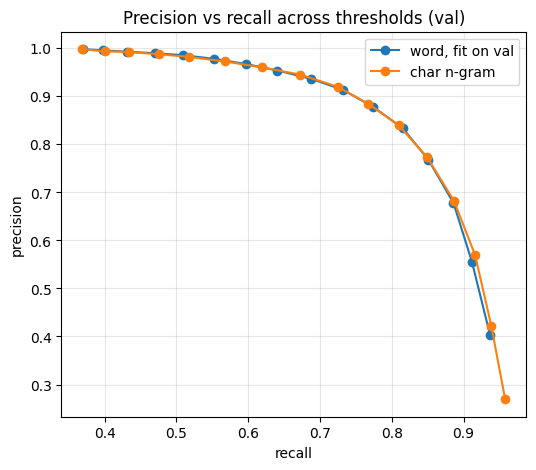

In [129]:
rows = {"word, fit on val": S2, "char n-gram": S3}
plt.figure(figsize=(6, 5))
for name, Sx in rows.items():
    ps, rs = [], []
    for t in np.arange(0.2, 0.96, 0.05):
        p, r = prec_rec(predict(Sx, t), lab)
        ps.append(p); rs.append(r)
    plt.plot(rs, ps, marker="o", label=name)
plt.xlabel("recall"); plt.ylabel("precision")
plt.title("Precision vs recall across thresholds (val)")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/results/pr_curve_word_vs_char.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Threshold analysis

Using word TF-IDF fitted on val.

| Threshold | Precision | Recall | Set-F1 |
|---|---|---|---|
| 0.20 | [ ] | [ ] | 0.4378* |
| [peak] | [ ] | [ ] | [ ] |
| 0.95 | [ ] | [ ] | [ ] |

*baseline run; re-read from the table i printed.

- **Low threshold:** [precision falls, recall near 1; many false positives.]
- **High threshold (0.95):** precision is 0.998 but recall is 0.370. A
  listing that predicts only itself already scores a recall of 0.323, so
  at 0.95 the model finds only about 0.05 beyond that: nearly every true
  partner is missed.
- **Crossing point:** precision and recall cross at about [ ].

**Final threshold: 0.43**, the F1 maximum on val over a sweep from 0.30 to
0.50 in steps of 0.01 (val F1 0.7770). The curve is flat here: 0.40 and
0.45 are within 0.002, so the exact value matters little. The test split
was not used to choose it.

(np.float64(0.2), np.float64(0.403), np.float64(0.937), np.float64(0.5084))
(np.float64(0.25), np.float64(0.555), np.float64(0.912), np.float64(0.6319))
(np.float64(0.3), np.float64(0.678), np.float64(0.886), np.float64(0.7123))
(np.float64(0.35), np.float64(0.768), np.float64(0.851), np.float64(0.756))
(np.float64(0.4), np.float64(0.834), np.float64(0.815), np.float64(0.7763))
(np.float64(0.45), np.float64(0.878), np.float64(0.774), np.float64(0.7748))
(np.float64(0.5), np.float64(0.913), np.float64(0.732), np.float64(0.7649))
(np.float64(0.55), np.float64(0.936), np.float64(0.688), np.float64(0.7445))
(np.float64(0.6), np.float64(0.954), np.float64(0.641), np.float64(0.7173))
(np.float64(0.65), np.float64(0.967), np.float64(0.597), np.float64(0.6886))
(np.float64(0.7), np.float64(0.978), np.float64(0.552), np.float64(0.6562))
(np.float64(0.75), np.float64(0.986), np.float64(0.51), np.float64(0.6243))
(np.float64(0.8), np.float64(0.99), np.float64(0.471), np.float64(0.5928))
(np.float

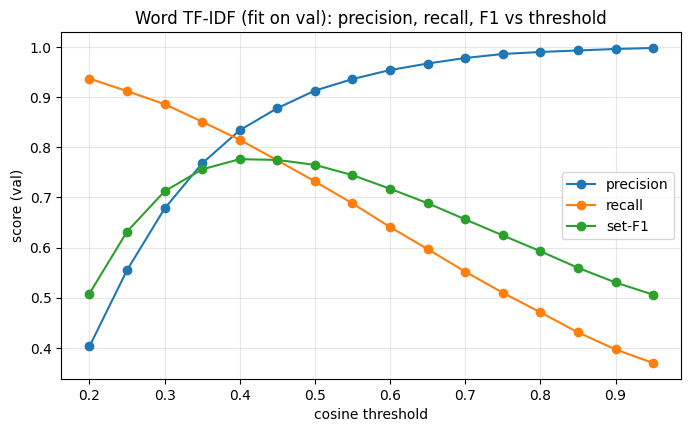

In [130]:
Sx = S2
rows = []
for t in np.arange(0.2, 0.96, 0.05):
    p, r = prec_rec(predict(Sx, t), lab)
    rows.append((round(t, 2), round(p, 3), round(r, 3), round(set_f1(predict(Sx, t), lab), 4)))
for row in rows: print(row)

t_, p_, r_, f_ = zip(*rows)
plt.figure(figsize=(8, 4.5))
plt.plot(t_, p_, marker="o", label="precision")
plt.plot(t_, r_, marker="o", label="recall")
plt.plot(t_, f_, marker="o", label="set-F1")
plt.xlabel("cosine threshold"); plt.ylabel("score (val)")
plt.title("Word TF-IDF (fit on val): precision, recall, F1 vs threshold")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/results/pr_f1_vs_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

In [131]:
g = pd.Series(lab).map(pd.Series(lab).value_counts()).values
print("self-only recall:", round((1 / g).mean(), 3))

self-only recall: 0.323


In [132]:
fine = [(round(t, 2), float(set_f1(predict(S2, t), lab))) for t in np.arange(0.30, 0.51, 0.01)]
best_t, best_f = max(fine, key=lambda r: r[1])
print("final threshold:", best_t, round(best_f, 4))

final threshold: 0.43 0.777


In [134]:
lab_t = test.label_group.values
vec_t = TfidfVectorizer(lowercase=True)
vec_t.fit(test.title)
St = cosine_similarity(vec_t.transform(test.title))
np.fill_diagonal(St, 1.0)

g_t = pd.Series(lab_t).map(pd.Series(lab_t).value_counts()).values
print("test F1   :", round(set_f1(predict(St, best_t), lab_t), 4))
print("test floor:", round((2 / (g_t + 1)).mean(), 4))

test F1   : 0.7741
test floor: 0.4401


| Experiment | Representation | Similarity | Threshold | Val F1 | Test F1 |
|---|---|---|---|---|---|
| Baseline | word TF-IDF, fit on train | cosine | 0.45 | 0.7632 | not run |
| 1 | word TF-IDF, single chars kept | cosine | 0.45 | 0.7650 | not run |
| 2 (final) | word TF-IDF, fit on val/test titles | cosine | 0.43 | 0.7770 | 0.7741 |
| 3 | char n-grams (2-4), fit on val | cosine | 0.45 | 0.7774 | not run |

Floors: val 0.4629, test 0.4401. Only the final method was run on test.

In [136]:
!pip install -q sentence-transformers

In [137]:
from sentence_transformers import SentenceTransformer
import time

t0 = time.time()
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
E = model.encode(val.title.tolist(), batch_size=128,
                 normalize_embeddings=True, show_progress_bar=True)
S4 = E @ E.T
np.fill_diagonal(S4, 1.0)
print("encode time:", round(time.time() - t0), "s", S4.shape)

res4 = [(round(t, 2), float(set_f1(predict(S4, t), lab)))
        for t in np.arange(0.3, 0.96, 0.05)]
for r in res4: print(r)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

encode time: 76 s (5115, 5115)
(np.float64(0.3), 0.011235359301882143)
(np.float64(0.35), 0.021289711358583326)
(np.float64(0.4), 0.042871472056447923)
(np.float64(0.45), 0.08646058182860973)
(np.float64(0.5), 0.16324131210299092)
(np.float64(0.55), 0.28033703845716557)
(np.float64(0.6), 0.41586344202403996)
(np.float64(0.65), 0.5398172264220945)
(np.float64(0.7), 0.6132705097774561)
(np.float64(0.75), 0.6424114483308445)
(np.float64(0.8), 0.6342466720995197)
(np.float64(0.85), 0.6023414537067435)
(np.float64(0.9), 0.5577291818456571)
(np.float64(0.95), 0.5155089087473628)


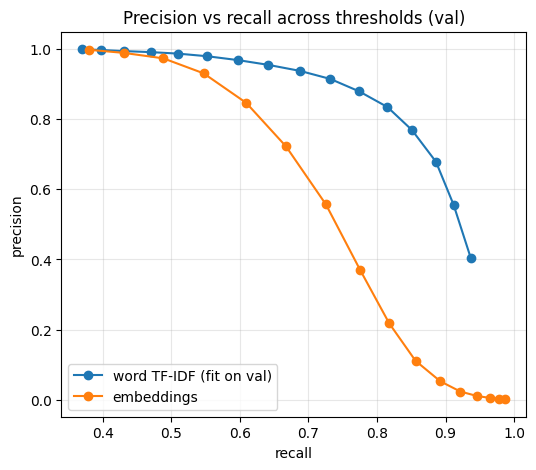

In [138]:
plt.figure(figsize=(6, 5))
for name, Sx in {"word TF-IDF (fit on val)": S2, "embeddings": S4}.items():
    ps, rs = [], []
    for t in np.arange(0.2, 0.96, 0.05):
        p, r = prec_rec(predict(Sx, t), lab)
        ps.append(p); rs.append(r)
    plt.plot(rs, ps, marker="o", label=name)
plt.xlabel("recall"); plt.ylabel("precision"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Precision vs recall across thresholds (val)")
plt.savefig("/kaggle/working/results/pr_curve_word_vs_embed.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [139]:
iu = np.triu_indices(len(lab), k=1)
same = (lab[iu[0]] == lab[iu[1]])
rng = np.random.default_rng(0)
sel = rng.choice(len(iu[0]), 400000, replace=False)
for name, Sx in {"word TF-IDF": S2, "embeddings": S4}.items():
    v = Sx[iu[0][sel], iu[1][sel]]
    m = same[sel]
    print(name, "| true pairs mean:", round(v[m].mean(), 3),
          "| other pairs mean:", round(v[~m].mean(), 3),
          "| other pairs 99th pct:", round(np.percentile(v[~m], 99), 3))

word TF-IDF | true pairs mean: 0.506 | other pairs mean: 0.004 | other pairs 99th pct: 0.103
embeddings | true pairs mean: 0.653 | other pairs mean: 0.219 | other pairs 99th pct: 0.557


In [141]:
for r in res4:
    print(r)

best4 = max(res4, key=lambda r: r[1])
print("best embeddings:", best4)

(np.float64(0.3), 0.011235359301882143)
(np.float64(0.35), 0.021289711358583326)
(np.float64(0.4), 0.042871472056447923)
(np.float64(0.45), 0.08646058182860973)
(np.float64(0.5), 0.16324131210299092)
(np.float64(0.55), 0.28033703845716557)
(np.float64(0.6), 0.41586344202403996)
(np.float64(0.65), 0.5398172264220945)
(np.float64(0.7), 0.6132705097774561)
(np.float64(0.75), 0.6424114483308445)
(np.float64(0.8), 0.6342466720995197)
(np.float64(0.85), 0.6023414537067435)
(np.float64(0.9), 0.5577291818456571)
(np.float64(0.95), 0.5155089087473628)
best embeddings: (np.float64(0.75), 0.6424114483308445)


In [140]:
print("true pairs in sample:", int(m.sum()))


true pairs in sample: 333


## Answers to the questions to consider

**How should two similar product titles be represented mathematically?**
As vectors, so that similarity becomes a distance or an angle. I used
TF-IDF: each title is a sparse vector over the vocabulary, with each word
weighted by how often it appears in the title (tf) and how rare it is
across titles (idf). The vectors are length-normalised, so the cosine of
the angle between two titles measures how much distinctive vocabulary they
share. A threshold on that cosine turns a score into a match decision.

**What makes TF-IDF effective or ineffective for this problem?**
Effective: it is fast, needs no training, and rewards shared distinctive
words. It reached a val set-F1 of 0.777 against a floor of 0.463, and
formatting differences ("S40 / M34" vs "S40/M34") scored 1.0. A single
brand word was enough to match "Saringan Air Zernii / Filter Penyaring Air"
with "ZERNII WATER FILTER ALAT LENGKAP" (0.45).
Ineffective: it only sees words, so it misses synonyms ("gula darah" vs
"glukosa"), truncations ("tablets" vs "tab") and titles with no shared
word ("CLB / GB GLOW..." vs "AYY SKINCARE...", score 0.0). It
also depends
on the vocabulary it was fitted on: RT100Q and RT130 were absent from the
train vocabulary and were ignored, and the default tokenizer dropped
single-character tokens such as the "8" in "8 Watt".

**Would character-level features be useful?**
In aggregate, no, in my experiment. Character n-grams (2 to 4) gave val F1
0.7774 against 0.7763 for word TF-IDF fitted the same way. At threshold
0.45 recall rose by 0.036 and precision fell by 0.039, and the
precision-recall curves overlap from recall 0.4 to 0.85, so the recall gain
was movement along one curve. I did not inspect individual pairs, so they
may still help specific truncation and typo cases, and they cannot separate
variants that differ only by a code.

**Why might semantic embeddings outperform keyword-based approaches?**
In principle they link titles with similar meaning but no shared words. I
tested this with paraphrase-multilingual-MiniLM-L12-v2 on the val titles.
It did not outperform word TF-IDF: its best val set-F1 was 0.6424 (at
threshold 0.75) against 0.7770, and its precision-recall curve lies below
TF-IDF's from recall 0.5 onward. A similarity check on a random sample of
400,000 val pairs (333 true pairs) shows why: unrelated pairs score a mean
of 0.219 with embeddings against 0.004 with TF-IDF, so different products
sit close together and a threshold that recovers true partners also admits
many wrong ones. This is one pretrained model without fine-tuning on short,
code-heavy, mixed-language titles, so it does not show that embeddings
cannot help here.

**What happens when two different products have very similar titles?**
They are false matches. Ecolink LED 8 Watt vs 6 Watt scored 1.0 because
the tokenizer dropped the digits; keeping single characters lowered it only
to 0.931. Two powerbank titles differing in RT100Q vs RT130 scored 1.0,
falling to 0.906 once the codes were in the vocabulary. Some titles are
identical across different groups (the 106 found in Part A). A single
threshold cannot remove these: thresholds high enough to separate them
(0.90, 0.95) scored near the floor in the baseline sweep.

**What happens when the same product has completely different titles?**
They are missed matches, and text alone cannot recover them. Pairs with no
shared word scored 0.0, and synonym pairs ("Easy Touch Gula darah" vs
"Strip Easy Touch Glukosa") fall just below the threshold. One listing
("Termurah Eric summers ... gamis") missed five partners at 0.0; I do not
know whether that group is broad or noisy. Part A showed the same product
photographed and titled in many ways (the Viva group), which is the case
for adding the image channel in Part C.

## Conclusions

- Word TF-IDF with cosine similarity is a strong baseline: val set-F1
  0.777 and test 0.774, against floors of 0.463 and 0.440. It closes about
  60% of the gap between the floor and a perfect score.
- Its remaining errors are of two kinds. False matches come from variants
  that differ in one number or code (8 Watt vs 6 Watt, RT100Q vs RT130) or
  from identical titles in different groups. Missed matches come from
  synonyms, truncations and titles with no shared word.
- Small implementation choices mattered: the default tokenizer dropped
  single characters, and a vectoriser fitted on train ignored words that
  appear only in the pool being searched (+0.013 F1 when fitted on val).
- Character n-grams did not help in aggregate: the precision-recall curves
  overlap, so their recall gain at a fixed threshold was movement along
  one curve.
- The threshold is a trade-off with a flat top (0.40 to 0.45 within 0.002).
  A single threshold cannot separate near-identical variant titles without
  losing recall elsewhere.
- Not done: sentence embeddings, and a stemmer or lemmatiser (mixed
  Indonesian and English titles, and a risk of mangling model codes).
- Text alone has a ceiling here, which is the case for combining it with
  the image channel in the later parts.